In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").values.ravel()
y_test = pd.read_csv(data_dir / "y_test.csv").values.ravel()

print("Loaded:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Loaded:
X_train: (227972, 35)
X_test:  (10852, 35)
y_train: (227972,)
y_test:  (10852,)


In [3]:
from src.predictors.predictors import EnsembleLearner
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


def print_evaluation(sub_model, X_train, X_test, y_train, y_test):
    sub_model_eval = clone(sub_model)
    sub_model_eval.fit(X_train, y_train)
    results = evaluate_classifier(
        sub_model_eval,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    print_classifier_results(results)

model = EnsembleLearner(meta_test_size=0.15)
print("Initializing model...")

Initializing model...


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Add Logistic Regression (Add scaling and L2 regularization)
logistic_regression = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    l1_ratio=0,
    max_iter=10000
)
print_evaluation(logistic_regression, X_train, X_test, y_train, y_test)
model.add_learner("Logistic Regression (L2)", logistic_regression)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 71.67%
Test accuracy   : 70.20%

Train log loss  : 0.5432
Test log loss   : 0.5548

Train ROC-AUC   : 0.7965
Test ROC-AUC    : 0.7831

Train confusion matrix:
[[81689 32297]
 [32297 81689]]

Test confusion matrix:
[[3809 1617]
 [1617 3809]]


In [5]:
from lightgbm import LGBMClassifier

# Add LightGBM (The dominant algorithm for Men's data)
lightgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
)
print_evaluation(lightgbm, X_train, X_test, y_train, y_test)
model.add_learner("LightGBM", lightgbm)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 72.61%
Test accuracy   : 70.53%

Train log loss  : 0.5292
Test log loss   : 0.5515

Train ROC-AUC   : 0.8085
Test ROC-AUC    : 0.7870

Train confusion matrix:
[[82745 31241]
 [31202 82784]]

Test confusion matrix:
[[3825 1601]
 [1597 3829]]


In [6]:
from xgboost import XGBClassifier

# Add XGBoost (Constrain depth to prevent memorization)
xgboost = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
)
print_evaluation(xgboost, X_train, X_test, y_train, y_test)
model.add_learner("XGBoost", xgboost)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 73.01%
Test accuracy   : 70.72%

Train log loss  : 0.5240
Test log loss   : 0.5497

Train ROC-AUC   : 0.8131
Test ROC-AUC    : 0.7883

Train confusion matrix:
[[83200 30786]
 [30753 83233]]

Test confusion matrix:
[[3838 1588]
 [1589 3837]]


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Add Random Forest
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
print_evaluation(random_forest, X_train, X_test, y_train, y_test)
model.add_learner("Random Forest", random_forest)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 75.78%
Test accuracy   : 70.73%

Train log loss  : 0.4944
Test log loss   : 0.5514

Train ROC-AUC   : 0.8457
Test ROC-AUC    : 0.7861

Train confusion matrix:
[[86317 27669]
 [27539 86447]]

Test confusion matrix:
[[3833 1593]
 [1583 3843]]


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add KNN classifier
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="distance",
        metric="minkowski",
        p=2,
    ))
])
print_evaluation(knn, X_train, X_test, y_train, y_test)
model.add_learner("KNN Classifier", knn)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 100.00%
Test accuracy   : 69.48%

Train log loss  : 0.0000
Test log loss   : 0.5838

Train ROC-AUC   : 1.0000
Test ROC-AUC    : 0.7719

Train confusion matrix:
[[113986      0]
 [     0 113986]]

Test confusion matrix:
[[3770 1656]
 [1656 3770]]


In [9]:
from sklearn.neural_network import MLPClassifier

# Add Basic Neural Network
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42,
    ))
])
print_evaluation(mlp, X_train, X_test, y_train, y_test)
model.add_learner("Basic Neural Network", mlp)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 72.20%
Test accuracy   : 70.25%

Train log loss  : 0.5364
Test log loss   : 0.5527

Train ROC-AUC   : 0.8024
Test ROC-AUC    : 0.7860

Train confusion matrix:
[[81963 32023]
 [31363 82623]]

Test confusion matrix:
[[3791 1635]
 [1593 3833]]


Partitioning data to prevent leakage...
Training base learners...
Logistic Regression (L2) train=0.7158  test=0.7219
LightGBM             train=0.7267  test=0.7234
XGBoost              train=0.7310  test=0.7230
Random Forest        train=0.7608  test=0.7210
KNN Classifier       train=1.0000  test=0.7129
Basic Neural Network train=0.7211  test=0.7210
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.8474 0.8529 0.8166 0.241  0.846 ]
 [0.8474 1.     0.9531 0.8817 0.2486 0.8604]
 [0.8529 0.9531 1.     0.8899 0.2545 0.8665]
 [0.8166 0.8817 0.8899 1.     0.2814 0.8159]
 [0.241  0.2486 0.2545 0.2814 1.     0.2396]
 [0.846  0.8604 0.8665 0.8159 0.2396 1.    ]]


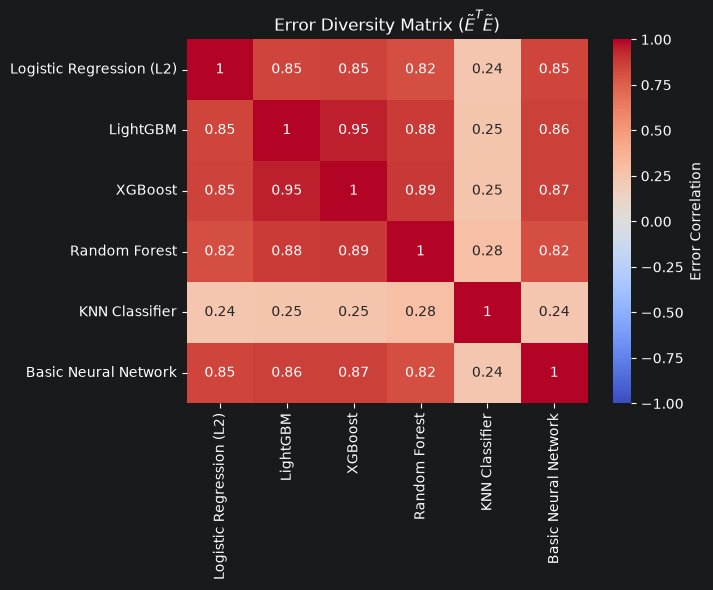

In [10]:
# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

In [11]:
# Where did we end up
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)
print_classifier_results(results)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 73.35%
Test accuracy   : 70.83%

Train log loss  : 0.5224
Test log loss   : 0.5554

Train ROC-AUC   : 0.8176
Test ROC-AUC    : 0.7883

Train confusion matrix:
[[84000 29986]
 [30774 83212]]

Test confusion matrix:
[[3857 1569]
 [1596 3830]]
